In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf
from statsmodels.tsa.seasonal import STL
from scipy.signal import find_peaks

In [11]:
# 1. 순수 Numpy Array 데이터 준비 (예시: 주기가 12인 가상 데이터)
np.random.seed(42)
n_samples = 240
time = np.arange(n_samples)

# 트렌드, 계절성(12 주기), 잔차 생성 및 합성
trend_part = 0.05 * time + 2
seasonal_part = 5 * np.sin(2 * np.pi * time / 12)
residual_part = np.random.normal(0, 1, n_samples)

# 최하단 데이터인 ts_array는 완전한 1차원 numpy array입니다.
ts_array = trend_part + seasonal_part + residual_part

ts_array

array([ 2.49671415,  4.4117357 ,  7.07781556,  8.67302986,  6.29597364,
        4.51586304,  3.87921282,  0.61743473, -2.3996014 , -2.00743996,
       -2.29354471, -0.41572975,  2.84196227,  3.23671976,  5.30520919,
        7.18771247,  6.1172959 ,  5.66424733,  1.99197592, -0.9623037 ,
        0.13552175, -2.1757763 , -1.16259881, -0.77474819,  2.65561728,
        5.86092259,  6.47913344,  8.72569802,  7.12948833,  5.65830625,
        2.89829339,  2.90227818, -0.74362424, -2.40771093,  0.19241789,
        0.02915635,  4.0088636 ,  4.39032988,  6.90194097,  9.14686124,
        9.0685936 ,  6.72136828,  3.98435172,  1.3488963 , -1.60864901,
       -1.46984421, -0.49076579,  2.90712223,  4.74361829,  5.18695984,
        9.15421099,  9.16491772,  8.25320502,  7.76167629,  5.73099952,
        3.18128012, -0.36934454, -0.45921238,  0.90113641,  3.42554513,
        4.52082576,  7.36434102,  8.32379204,  8.95379338, 10.34265284,
        9.10624003,  5.22798988,  3.8535329 ,  1.43150901, -0.19

In [12]:
# 2. numpy array에서 ACF 계산 및 find_peaks로 최적 period 도출
nlags = min(len(ts_array) // 2, 50)
acf_values = acf(ts_array, nlags=nlags, fft=True)

# 시차(Lag) 0, 1, 2는 초기 자기상관성 때문에 높으므로 제외하고 인덱스 3부터 피크 탐색
peaks, _ = find_peaks(acf_values[3:], prominence=0.05)
peaks = peaks + 3  # 잘라낸 인덱스 보정

if len(peaks) > 0:
    detected_period = peaks[0]  # 가장 먼저 발견된 유의미한 피크를 주기로 채택
    print(f"[성공] 탐색된 최적 주기(Period): {detected_period}")
else:
    detected_period = 1
    print("[알림] 주기성을 찾지 못해 기본값(1)을 사용합니다.")

[성공] 탐색된 최적 주기(Period): 12


In [13]:
# 3. 도출된 period를 입력하여 STL 분해 실행
# 입력값이 numpy array이므로, 결과물(trend, seasonal, resid)도 모두 numpy array로 반환됩니다.
res = STL(ts_array, period=detected_period, robust=True).fit()

trend = res.trend
seasonal = res.seasonal
resid = res.resid


# 4. 트렌드 및 계절성 강도 계산 (Numpy 분산 함수 사용)
var_resid = np.var(resid)
var_trend_resid = np.var(trend + resid)
var_seasonal_resid = np.var(seasonal + resid)

trend_strength = max(0, 1 - var_resid / var_trend_resid)
seasonal_strength = max(0, 1 - var_resid / var_seasonal_resid)

print(f"-> 트렌드 강도 (F_T): {trend_strength:.4f}")
print(f"-> 계절성 강도 (F_S): {seasonal_strength:.4f}")

-> 트렌드 강도 (F_T): 0.9504
-> 계절성 강도 (F_S): 0.9484


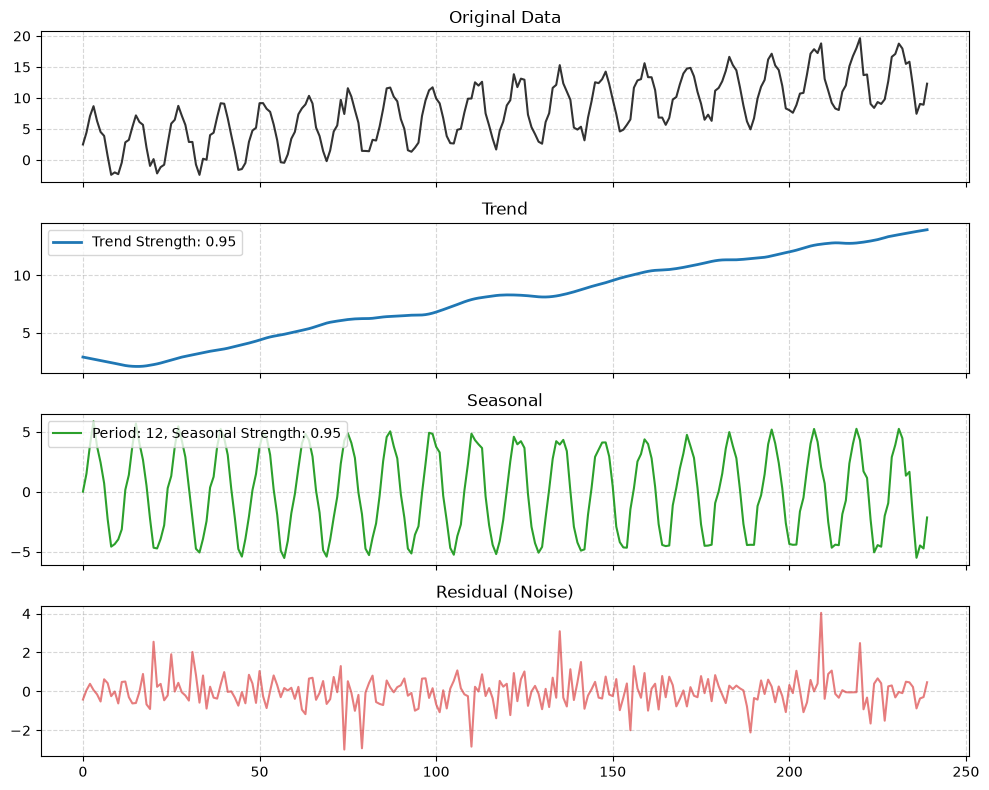

In [14]:
# 5. 시각화 (X축은 날짜 대신 단순 배열 인덱스로 표현됩니다)
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

axes[0].plot(ts_array, color='black', alpha=0.8)
axes[0].set_title('Original Data')
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].plot(trend, color='tab:blue', linewidth=2, label=f'Trend Strength: {trend_strength:.2f}')
axes[1].set_title('Trend')
axes[1].legend(loc='upper left')
axes[1].grid(True, linestyle='--', alpha=0.5)

axes[2].plot(seasonal, color='tab:green', label=f'Period: {detected_period}, Seasonal Strength: {seasonal_strength:.2f}')
axes[2].set_title('Seasonal')
axes[2].legend(loc='upper left')
axes[2].grid(True, linestyle='--', alpha=0.5)

axes[3].plot(resid, color='tab:red', alpha=0.6)
axes[3].set_title('Residual (Noise)')
axes[3].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

[안내] 탐색된 주기: 6 (무작위 데이터 특성상 우연히 잡힌 노이즈 피크일 수 있음)
-> 트렌드 강도 (F_T): 0.1182
-> 계절성 강도 (F_S): 0.2852


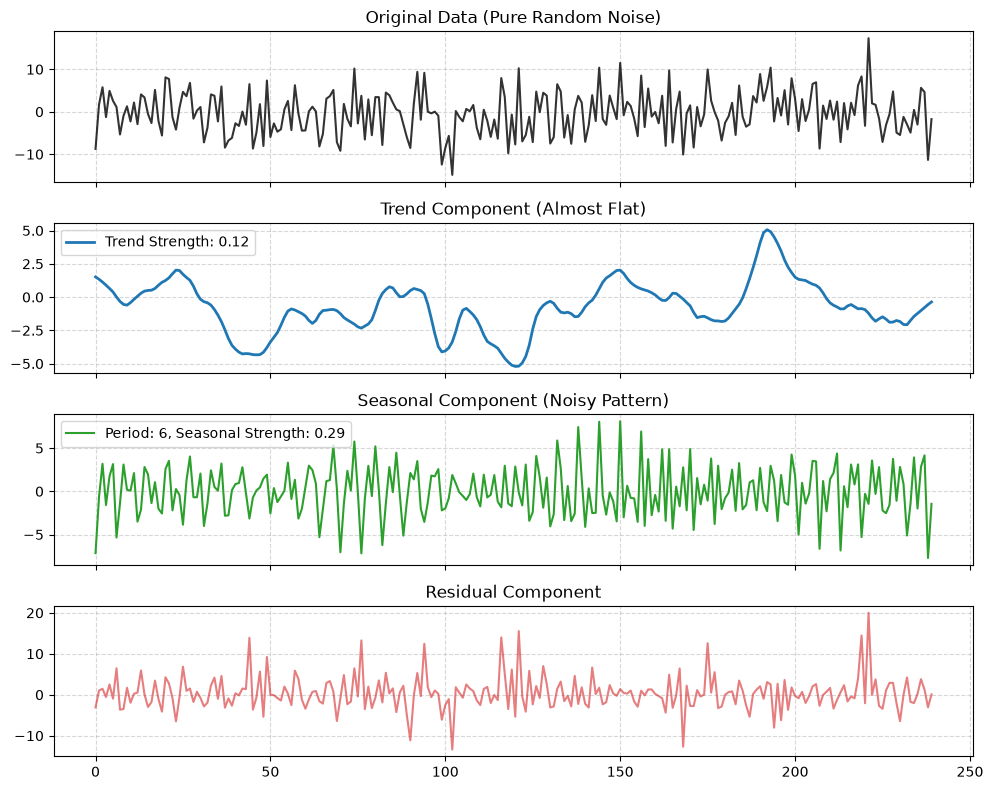

In [15]:
# 1. 특정 패턴이 없는 무작위 데이터(White Noise) 생성
np.random.seed(100)
n_samples = 240

# 트렌드와 계절성 없이 오직 평균이 0이고 표준편차가 5인 가우시안 노이즈만 생성합니다.
ts_array = np.random.normal(0, 5, n_samples)


# 2. ACF 및 find_peaks로 최적 period 도출 시도
nlags = min(len(ts_array) // 2, 50)
acf_values = acf(ts_array, nlags=nlags, fft=True)

# 무작위 데이터이므로 특정 시차에서 피크가 솟구치지 않습니다.
# prominence 조건을 만족하는 피크를 탐색합니다.
peaks, _ = find_peaks(acf_values[3:], prominence=0.05)
peaks = peaks + 3

if len(peaks) > 0:
    detected_period = peaks[0]
    print(f"[안내] 탐색된 주기: {detected_period} (무작위 데이터 특성상 우연히 잡힌 노이즈 피크일 수 있음)")
else:
    # 대개의 무작위 데이터는 피크가 검출되지 않아 기본값 1(주기 없음)로 설정됩니다.
    detected_period = 1
    print("[안내] 주기성이 검출되지 않았습니다. 기본값(1)을 사용합니다.")

# STL 분해는 최소 2 이상의 주기를 요구하므로, 주기가 없거나 1로 잡히면 최소 주기인 2로 설정하여 분해를 시도합니다.
stl_period = detected_period if detected_period > 1 else 2


# 3. STL 분해 실행
res = STL(ts_array, period=stl_period, robust=True).fit()

trend = res.trend
seasonal = res.seasonal
resid = res.resid


# 4. 트렌드 및 계절성 강도 계산
var_resid = np.var(resid)
var_trend_resid = np.var(trend + resid)
var_seasonal_resid = np.var(seasonal + resid)

trend_strength = max(0, 1 - var_resid / var_trend_resid)
seasonal_strength = max(0, 1 - var_resid / var_seasonal_resid)

print(f"-> 트렌드 강도 (F_T): {trend_strength:.4f}")
print(f"-> 계절성 강도 (F_S): {seasonal_strength:.4f}")


# 5. 시각화
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

axes[0].plot(ts_array, color='black', alpha=0.8)
axes[0].set_title('Original Data (Pure Random Noise)')
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].plot(trend, color='tab:blue', linewidth=2, label=f'Trend Strength: {trend_strength:.2f}')
axes[1].set_title('Trend Component (Almost Flat)')
axes[1].legend(loc='upper left')
axes[1].grid(True, linestyle='--', alpha=0.5)

axes[2].plot(seasonal, color='tab:green', label=f'Period: {stl_period}, Seasonal Strength: {seasonal_strength:.2f}')
axes[2].set_title('Seasonal Component (Noisy Pattern)')
axes[2].legend(loc='upper left')
axes[2].grid(True, linestyle='--', alpha=0.5)

axes[3].plot(resid, color='tab:red', alpha=0.6)
axes[3].set_title('Residual Component')
axes[3].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

[안내] Pure FFT로 탐색된 지배적 주기: 240 (수학적 원리에 의해 하이퍼파라미터 없이 도출됨)
-> 트렌드 강도 (F_T): 1.0000
-> 계절성 강도 (F_S): 1.0000


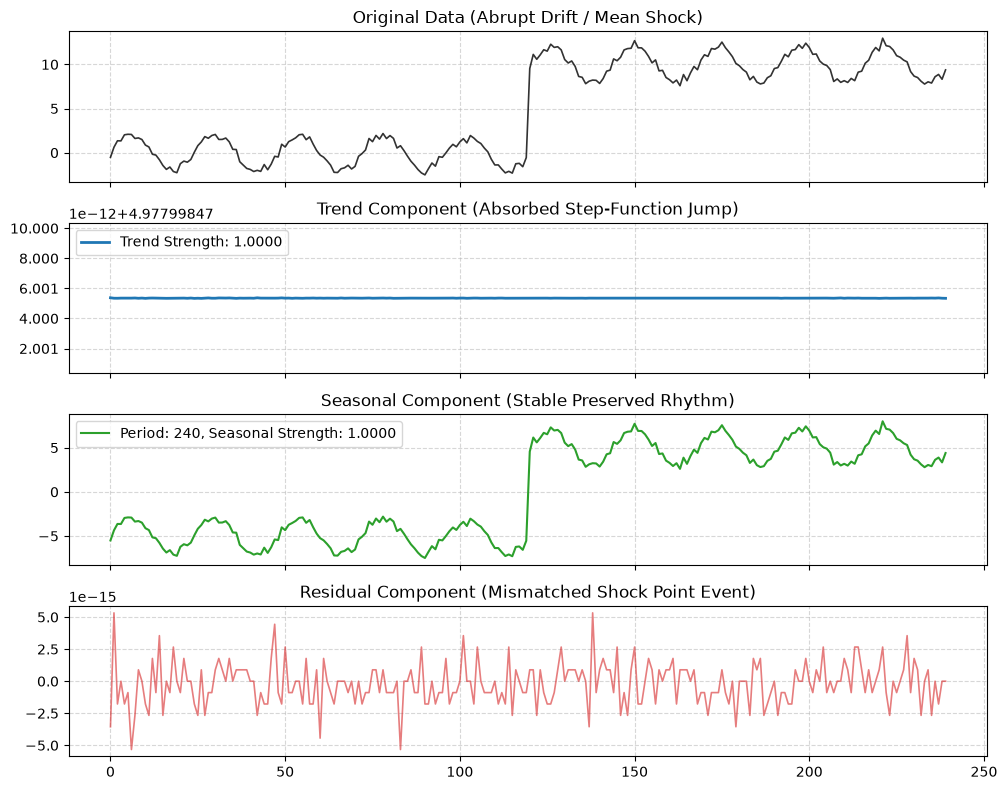

In [16]:
# 1. ⚡ Abrupt Drift를 포함한 복합 계절성 데이터 생성
np.random.seed(100)
n_samples = 240
t = np.arange(n_samples)

# 기저 신호: TSFM이 사전학습 분포에서 가장 잘 예측하는 뚜렷한 24시간 주기성(Seasonality) 신호
base_seasonality = 2.0 * np.sin(2 * np.pi * t / 24)
# 평시 가우시안 노이즈 주입
noise = np.random.normal(0, 0.3, n_samples)

# [핵심] Abrupt Drift 주입: t=120 (정확히 절반 시점) 기점으로 기조 평균축이 0에서 +10.0으로 불연속 점프(Mean Shock)
drift_signal = np.zeros(n_samples)
drift_signal[n_samples // 2:] = 10.0

# 최종 관측 데이터셋 합성 (우리 시스템의 Regime 3: Abrupt Shock 상태)
ts_array = base_seasonality + drift_signal + noise


# 2. 🔮 순수 푸리에 변환(Pure FFT Argmax) 기반 최적 period 도출
# 신호 전체의 평균을 제거하여 주파수 0(DC Component)으로 에너지가 쏠려 주기가 왜곡되는 현상 차단
detrended = ts_array - np.mean(ts_array)

fft_values = np.fft.fft(detrended)
fft_freqs = np.fft.fftfreq(n_samples, d=1.0) # 1시간 단위 샘플링 기준 (fs=1.0)

# 대칭성을 고려하여 양의 주파수 영역만 필터링
positive_mask = fft_freqs > 0
freqs = fft_freqs[positive_mask]
magnitudes = np.abs(fft_values)[positive_mask]

# find_peaks 없이 오직 에너지 진폭 스펙트럼이 가장 높은 '전역 최댓값(Global Maxima)'만 추적
dominant_freq_idx = np.argmax(magnitudes)
dominant_freq = freqs[dominant_freq_idx]

# 주파수의 역수를 취해 최종 지배적 주기(Period) 도출
detected_period = 1.0 / dominant_freq
detected_period_rounded = int(round(detected_period))

if detected_period_rounded > 1:
    print(f"[안내] Pure FFT로 탐색된 지배적 주기: {detected_period_rounded} (수학적 원리에 의해 하이퍼파라미터 없이 도출됨)")
else:
    print("[안내] 주기성이 검출되지 않았습니다. 기본값(1)을 사용합니다.")

# STL 분해의 최소 구동 조건 제어 (주기가 없거나 1로 잡히면 최소 주기인 2로 설정하여 분해 시도)
stl_period = detected_period_rounded if detected_period_rounded > 1 else 2


# 3. 📊 STL 분해 실행
# robust=True를 바인딩하여 t=120 시점의 거대한 계단형 쇼크가 계절성 성분을 오염시키지 않도록 규제화
res = STL(ts_array, period=stl_period, robust=True).fit()

trend = res.trend
seasonal = res.seasonal
resid = res.resid


# 4. 트렌드 및 계절성 강도 계산 (데이터 과학 표준 수식)
var_resid = np.var(resid)
var_trend_resid = np.var(trend + resid)
var_seasonal_resid = np.var(seasonal + resid)

trend_strength = max(0, 1 - var_resid / (var_trend_resid + 1e-8))
seasonal_strength = max(0, 1 - var_resid / (var_seasonal_resid + 1e-8))

print(f"-> 트렌드 강도 (F_T): {trend_strength:.4f}")
print(f"-> 계절성 강도 (F_S): {seasonal_strength:.4f}")


# 5. 시각화 (제공해주신 4단 분해 플롯 스타일 적용)
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

# Original Data Plot
axes[0].plot(ts_array, color='black', alpha=0.8, linewidth=1.2)
axes[0].set_title('Original Data (Abrupt Drift / Mean Shock)')
axes[0].grid(True, linestyle='--', alpha=0.5)

# Trend Component Plot
axes[1].plot(trend, color='tab:blue', linewidth=2, label=f'Trend Strength: {trend_strength:.4f}')
axes[1].set_title('Trend Component (Absorbed Step-Function Jump)')
axes[1].legend(loc='upper left')
axes[1].grid(True, linestyle='--', alpha=0.5)

# Seasonal Component Plot
axes[2].plot(seasonal, color='tab:green', label=f'Period: {stl_period}, Seasonal Strength: {seasonal_strength:.4f}')
axes[2].set_title('Seasonal Component (Stable Preserved Rhythm)')
axes[2].legend(loc='upper left')
axes[2].grid(True, linestyle='--', alpha=0.5)

# Residual Component Plot
axes[3].plot(resid, color='tab:red', alpha=0.6, linewidth=1.2)
axes[3].set_title('Residual Component (Mismatched Shock Point Event)')
axes[3].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

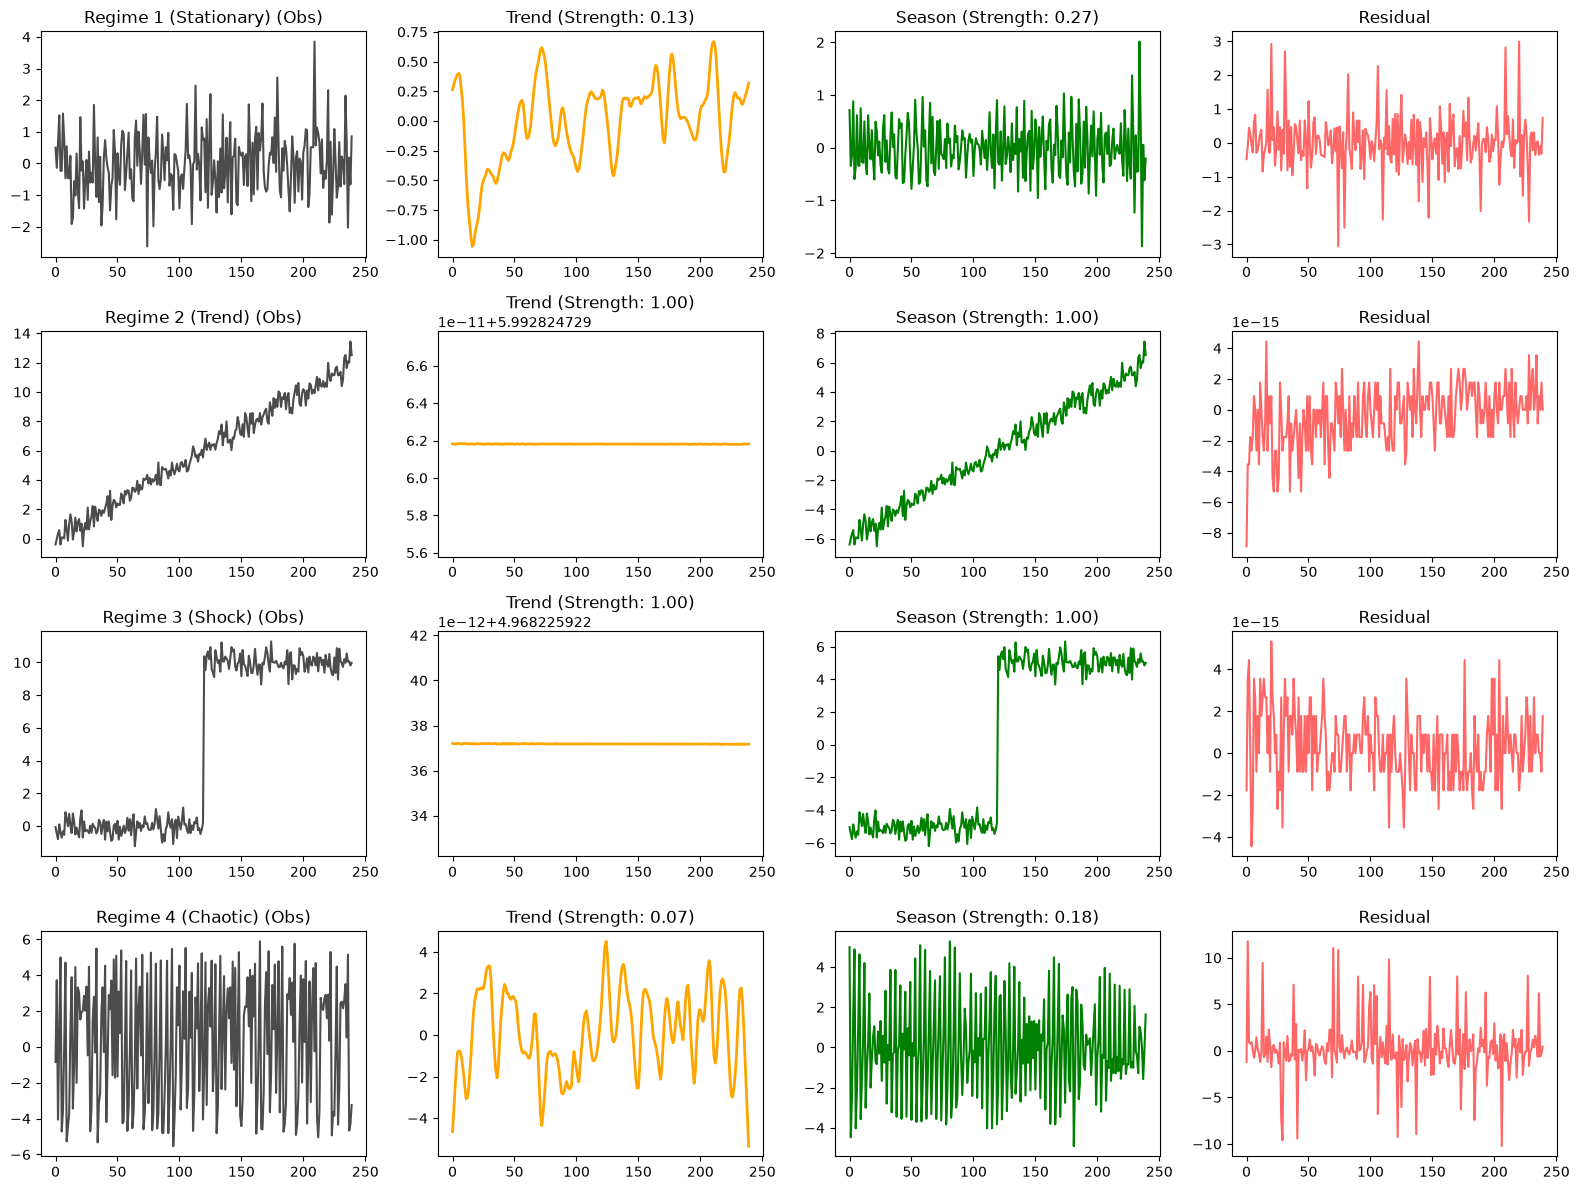

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL
import warnings

# 경고 메시지 억제
warnings.filterwarnings('ignore')

def generate_tsfm_3regime_data(length=240, seed=42):
    """Regime 1~4 데이터 생성기"""
    np.random.seed(seed)
    t = np.arange(length)
    r1 = np.random.normal(0, 1.0, length)
    r2 = 0.05 * t + np.random.normal(0, 0.5, length)
    r3 = np.random.normal(0, 0.5, length)
    r3[length // 2:] += 10.0
    chaotic = np.zeros(length)
    chaotic[0] = 0.4
    for i in range(1, length): chaotic[i] = 3.99 * chaotic[i-1] * (1 - chaotic[i-1])
    r4 = (chaotic - 0.5) * 10 + np.random.normal(0, 0.5, length)
    
    return {'Regime 1 (Stationary)': r1, 'Regime 2 (Trend)': r2, 
            'Regime 3 (Shock)': r3, 'Regime 4 (Chaotic)': r4}

def get_period_fft_robust(ts):
    """
    [핵심] find_peaks 제거, Pure FFT Argmax로 주기 도출
    주기성이 없을 경우 기본값 2를 반환하여 OverflowError 원천 차단
    """
    detrended = ts - np.mean(ts)
    fft_val = np.abs(np.fft.fft(detrended))
    freqs = np.fft.fftfreq(len(ts))
    
    # 0번 주파수(DC 성분) 제외하고 양의 주파수 영역만 필터링
    mask = freqs > 0
    fft_val = fft_val[mask]
    freqs = freqs[mask]
    
    if np.max(fft_val) < 1e-5: # 주기성 부재 시 안전장치
        return 2
    
    # 지배적 주파수 인덱스 추출 (가장 높은 에너지)
    idx = np.argmax(fft_val)
    dominant_freq = freqs[idx]
    
    # 0에 가까운 주파수 방지
    if dominant_freq < 1e-8:
        return 2
        
    period = 1.0 / dominant_freq
    return max(2, int(round(period)))

# 데이터 생성
data_dict = generate_tsfm_3regime_data()

# 시각화 루프
fig, axes = plt.subplots(4, 4, figsize=(16, 12))

for i, (name, series) in enumerate(data_dict.items()):
    # 1. 강건한 주기 도출
    period = get_period_fft_robust(series)
    
    # 2. Numpy STL 분해 (Pandas Index 필수 요구사항 우회)
    df_series = pd.Series(series, index=pd.RangeIndex(start=0, stop=len(series)))
    res = STL(df_series, period=period, robust=True).fit()
    
    # 3. 강도 계산
    f_t = max(0, 1 - np.var(res.resid) / (np.var(res.trend + res.resid) + 1e-8))
    f_s = max(0, 1 - np.var(res.resid) / (np.var(res.seasonal + res.resid) + 1e-8))
    
    # 4. 시각화
    axes[i, 0].plot(res.observed, color='black', alpha=0.7); axes[i, 0].set_title(f"{name} (Obs)")
    axes[i, 1].plot(res.trend, color='orange', linewidth=2); axes[i, 1].set_title(f"Trend (Strength: {f_t:.2f})")
    axes[i, 2].plot(res.seasonal, color='green'); axes[i, 2].set_title(f"Season (Strength: {f_s:.2f})")
    axes[i, 3].plot(res.resid, color='red', alpha=0.6); axes[i, 3].set_title("Residual")

plt.tight_layout()
plt.show()

Dominant Frequency: 0.041666666666666664 -> Detected Period: 24
Dominant Frequency: 0.004166666666666667 -> Detected Period: 240
Dominant Frequency: 0.16666666666666666 -> Detected Period: 6
Dominant Frequency: 0.041666666666666664 -> Detected Period: 24


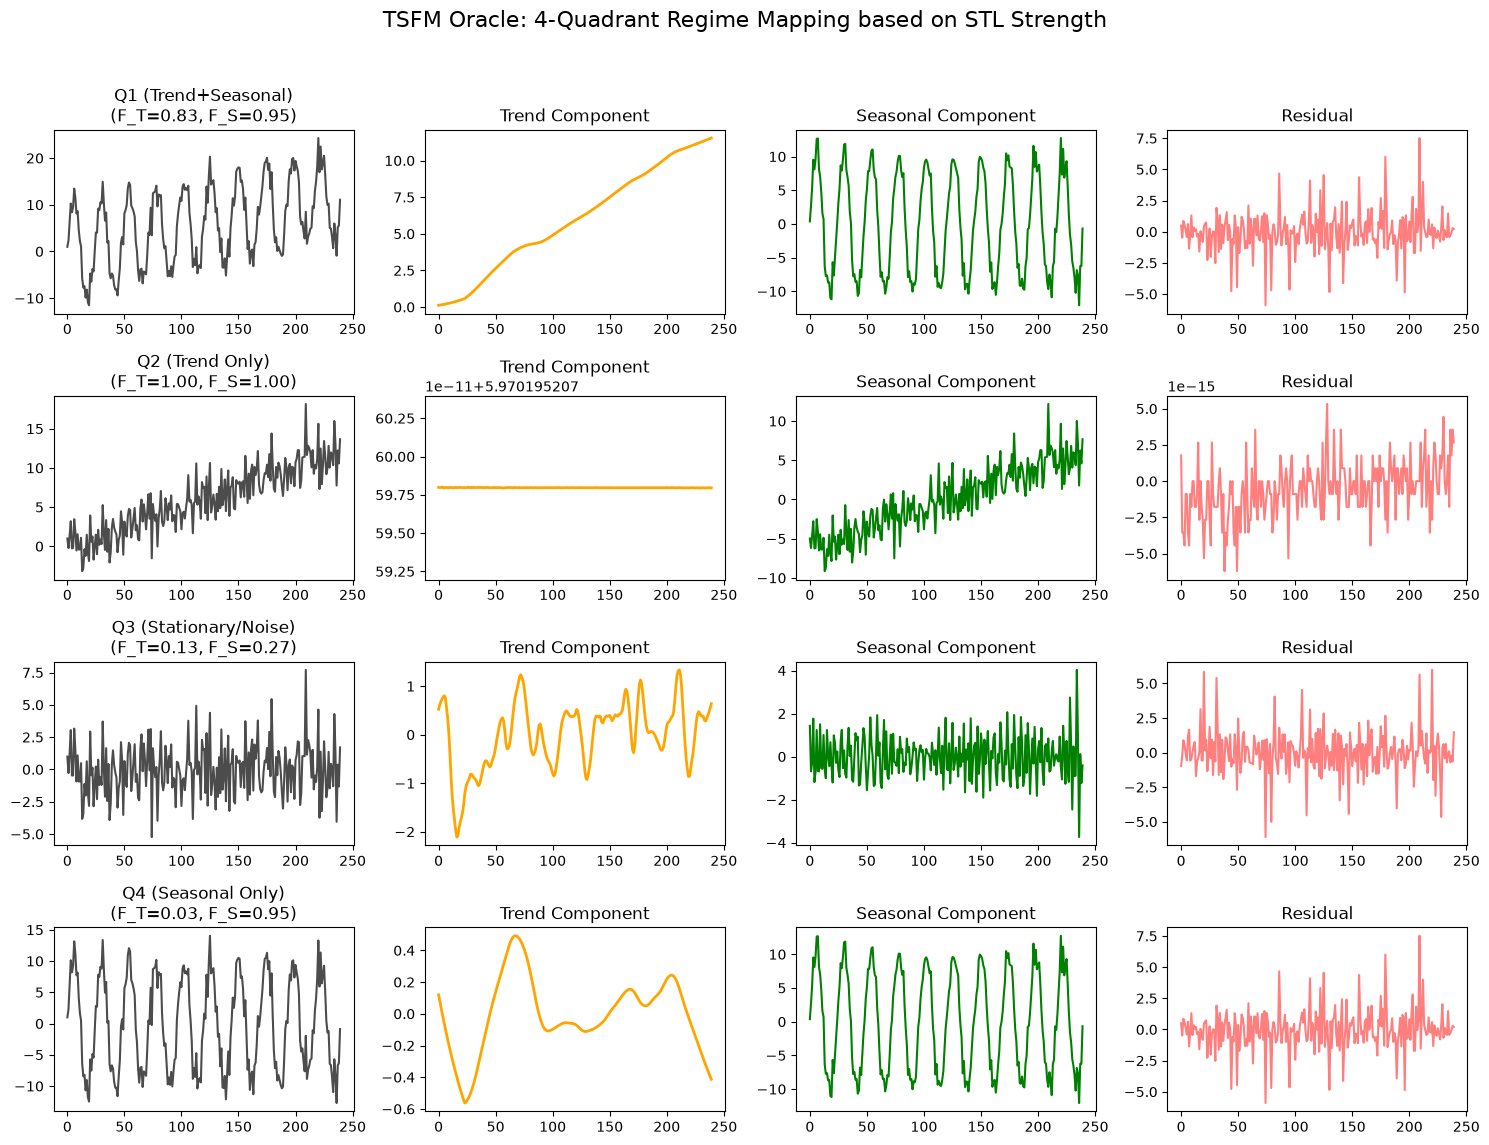

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL

def generate_quadrant_data(length=240, seed=42):
    """
    각 사분면(Q1~Q4)을 대표하는 Toy Data 생성기
    """
    np.random.seed(seed)
    t = np.arange(length)
    
    # 기본 구성요소
    trend = 0.05 * t  # 선형 트렌드
    seasonal = 10 * np.sin(2 * np.pi * t / 24)  # 24주기 계절성
    noise = np.random.normal(0, 2, length) # 잔차
    
    # 사분면별 데이터 구성
    data = {
        'Q1 (Trend+Seasonal)': trend + seasonal + noise,    # F_T > 0.64, F_S > 0.64
        'Q2 (Trend Only)': trend + noise,                   # F_T > 0.64, F_S < 0.64
        'Q3 (Stationary/Noise)': noise,                     # F_T < 0.64, F_S < 0.64
        'Q4 (Seasonal Only)': seasonal + noise              # F_T < 0.64, F_S > 0.64
    }
    return data

def get_period_fft_robust(ts):
    detrended = ts - np.mean(ts)
    fft_val = np.abs(np.fft.fft(detrended))
    freqs = np.fft.fftfreq(len(ts))
    mask = freqs > 0
    fft_val, freqs = fft_val[mask], freqs[mask]
    
    if np.max(fft_val) < 1e-5: return 2
    idx = np.argmax(fft_val)
    dominant_freq = freqs[idx]

    period = max(2, int(round(1.0 / dominant_freq))) if dominant_freq > 1e-8 else 2

    print('Dominant Frequency:', dominant_freq, '-> Detected Period:', period)

    return max(2, int(round(1.0 / dominant_freq))) if dominant_freq > 1e-8 else 2

# 데이터 생성
data_dict = generate_quadrant_data()

# 시각화: 4개의 행(사분면), 4개의 열(Obs, Trend, Season, Resid)
fig, axes = plt.subplots(4, 4, figsize=(15, 12))
fig.suptitle("TSFM Oracle: 4-Quadrant Regime Mapping based on STL Strength", fontsize=16)

for i, (name, series) in enumerate(data_dict.items()):
    period = get_period_fft_robust(series)
    res = STL(pd.Series(series), period=period, robust=True).fit()
    
    # 강도 계산
    f_t = max(0, 1 - np.var(res.resid) / (np.var(res.trend + res.resid) + 1e-8))
    f_s = max(0, 1 - np.var(res.resid) / (np.var(res.seasonal + res.resid) + 1e-8))
    
    # 4사분면 plot
    axes[i, 0].plot(res.observed, color='black', alpha=0.7); axes[i, 0].set_title(f"{name}\n(F_T={f_t:.2f}, F_S={f_s:.2f})")
    axes[i, 1].plot(res.trend, color='orange', linewidth=2); axes[i, 1].set_title(f"Trend Component")
    axes[i, 2].plot(res.seasonal, color='green'); axes[i, 2].set_title(f"Seasonal Component")
    axes[i, 3].plot(res.resid, color='red', alpha=0.5); axes[i, 3].set_title("Residual")

plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()

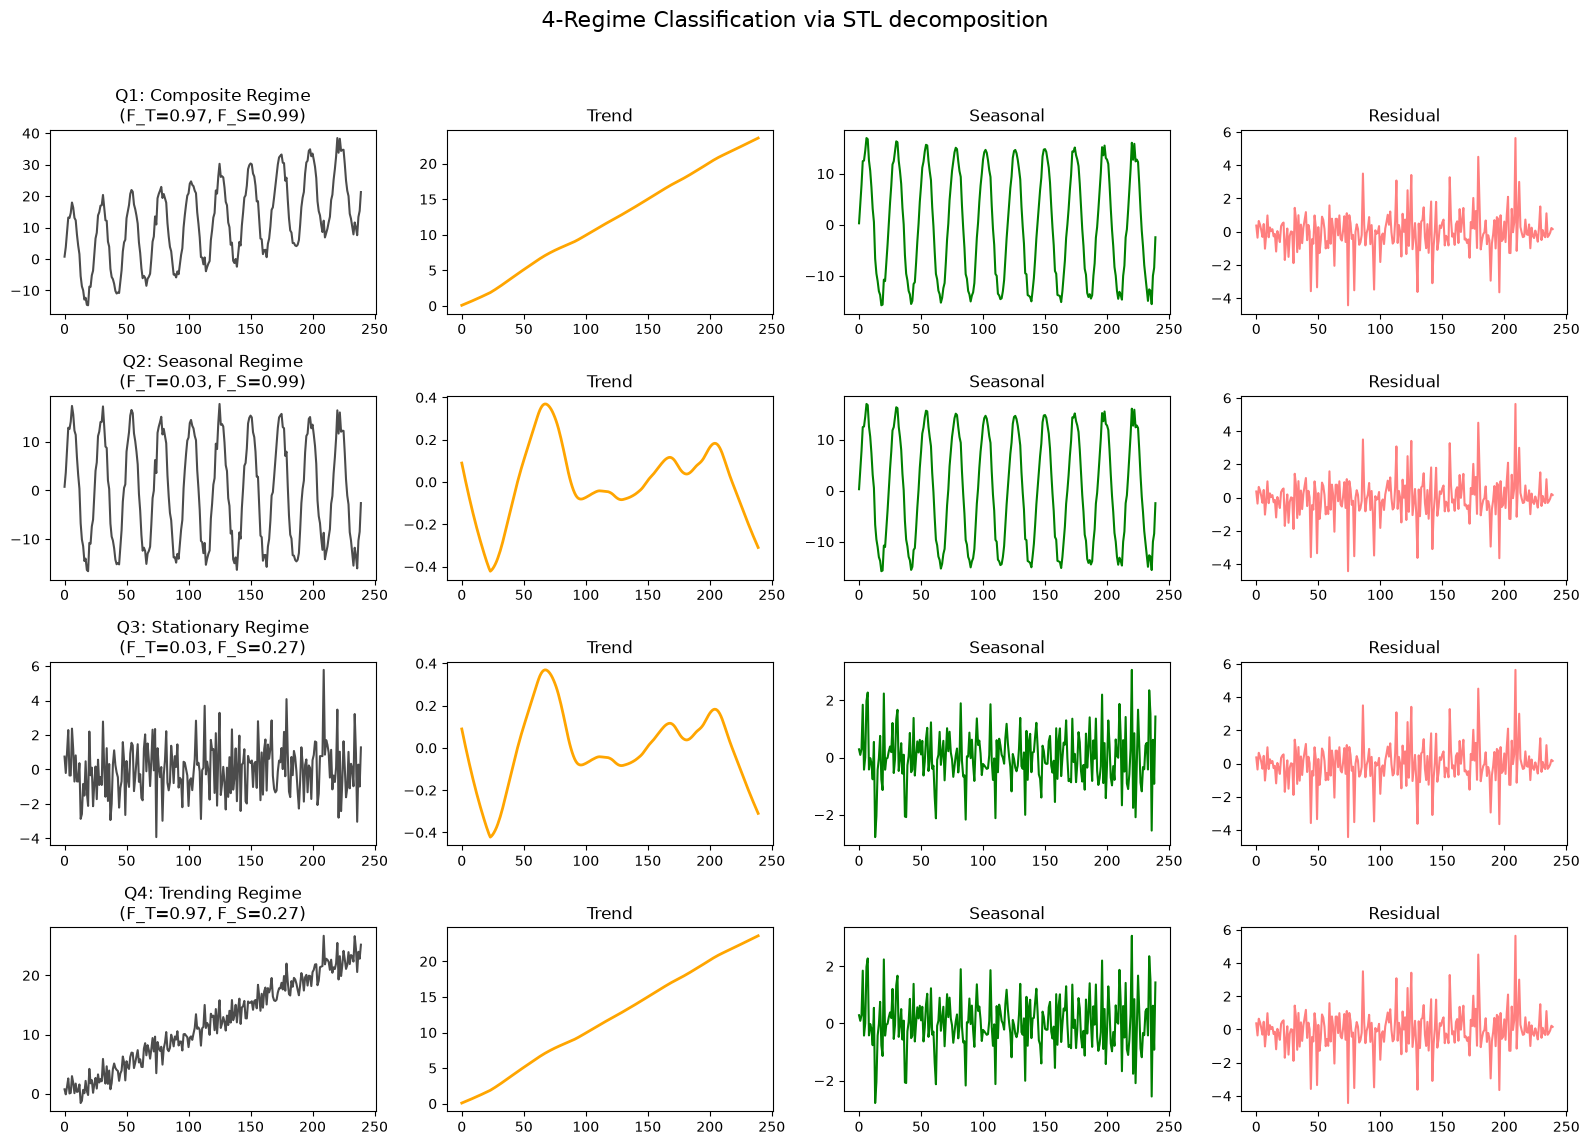

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL

def generate_robust_quadrant_data(length=240, seed=42):
    np.random.seed(seed)
    t = np.arange(length)
    
    # 기본 구성요소: 강도를 확실하게 확보하기 위해 계수 조정
    trend_comp = 0.1 * t
    seasonal_comp = 15 * np.sin(2 * np.pi * t / 24)
    noise = np.random.normal(0, 1.5, length)
    
    # 사분면별 구성
    return {
        'Q1: Composite Regime': trend_comp + seasonal_comp + noise, 
        'Q2: Seasonal Regime': seasonal_comp + noise,
        'Q3: Stationary Regime': noise,                         
        'Q4: Trending Regime': trend_comp + noise,                
    }

# 데이터 생성 및 분해 루프
data_dict = generate_robust_quadrant_data()
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
fig.suptitle("4-Regime Classification via STL decomposition", fontsize=16)

for i, (name, series) in enumerate(data_dict.items()):
    # 24주기 고정 (Toy Data의 특성 반영)
    res = STL(pd.Series(series), period=24, robust=True).fit()
    
    f_t = max(0, 1 - np.var(res.resid) / (np.var(res.trend + res.resid) + 1e-8))
    f_s = max(0, 1 - np.var(res.resid) / (np.var(res.seasonal + res.resid) + 1e-8))
    
    # 시각화
    axes[i, 0].plot(res.observed, color='black', alpha=0.7); axes[i, 0].set_title(f"{name}\n(F_T={f_t:.2f}, F_S={f_s:.2f})")
    axes[i, 1].plot(res.trend, color='orange', linewidth=2); axes[i, 1].set_title("Trend")
    axes[i, 2].plot(res.seasonal, color='green'); axes[i, 2].set_title("Seasonal")
    axes[i, 3].plot(res.resid, color='red', alpha=0.5); axes[i, 3].set_title("Residual")

plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()

In [21]:
import os
os.getcwd()

'c:\\Users\\wayne\\Desktop\\PythonProject\\TSFM_OPS\\TSFM\\src\\temp'

In [28]:
data_path = '../../data/Etth1.csv'
data = pd.read_csv(data_path)
data.head()
target = np.array(data['OT'])

len(target)

17420

총 분석 대상 시퀀스 수: 173개
원천 신호 동적 주기 분석 및 레짐 매핑 중...
f{i+1}/{num_sequences} - f{i+1}/{num_sequences} - f{i+1}/{num_sequences} - f{i+1}/{num_sequences} - f{i+1}/{num_sequences} - f{i+1}/{num_sequences} - f{i+1}/{num_sequences} - f{i+1}/{num_sequences} - f{i+1}/{num_sequences} - f{i+1}/{num_sequences} - f{i+1}/{num_sequences} - f{i+1}/{num_sequences} - f{i+1}/{num_sequences} - f{i+1}/{num_sequences} - f{i+1}/{num_sequences} - f{i+1}/{num_sequences} - f{i+1}/{num_sequences} - f{i+1}/{num_sequences} - f{i+1}/{num_sequences} - f{i+1}/{num_sequences} - f{i+1}/{num_sequences} - f{i+1}/{num_sequences} - f{i+1}/{num_sequences} - f{i+1}/{num_sequences} - f{i+1}/{num_sequences} - f{i+1}/{num_sequences} - f{i+1}/{num_sequences} - f{i+1}/{num_sequences} - f{i+1}/{num_sequences} - f{i+1}/{num_sequences} - f{i+1}/{num_sequences} - f{i+1}/{num_sequences} - f{i+1}/{num_sequences} - f{i+1}/{num_sequences} - f{i+1}/{num_sequences} - f{i+1}/{num_sequences} - f{i+1}/{num_sequences} - f{i+1}/{num_sequences} - f{

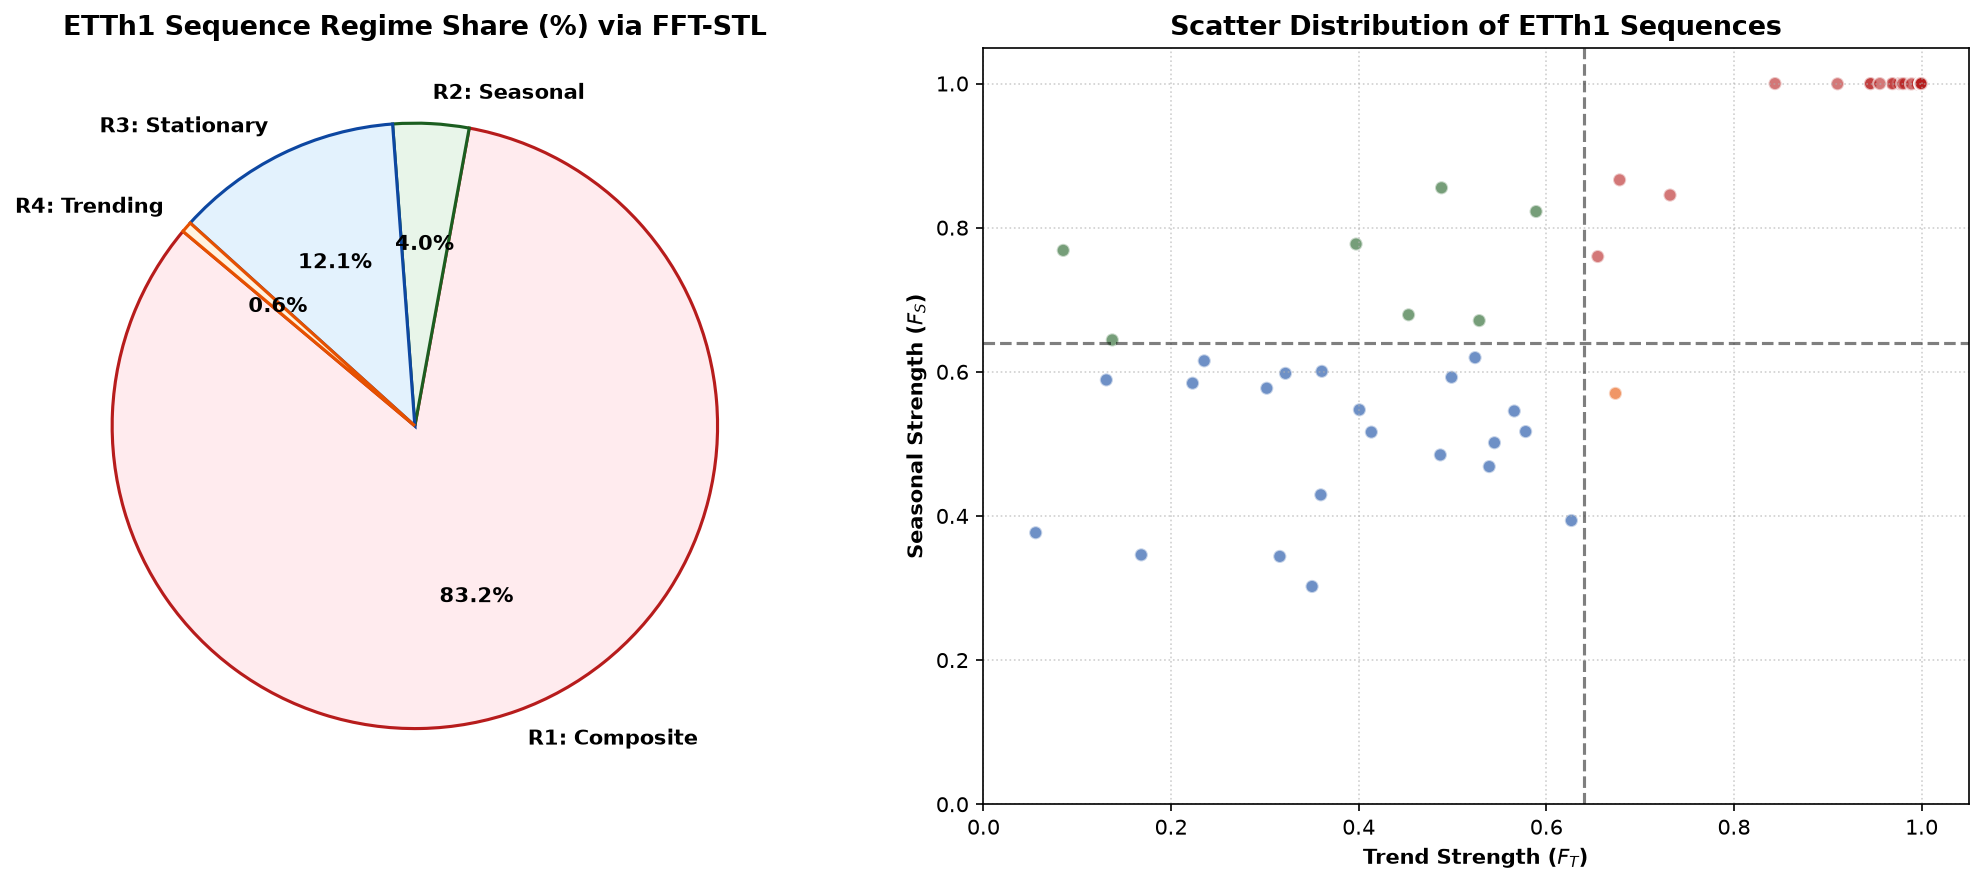

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL

# --- [기존 작성 코드 기점 연장] ---
# data_path = '../../data/Etth1.csv'
# data = pd.read_csv(data_path)
# target = np.array(data['OT'])

# 실험 조건 설정
context_length = 200
step_size = 100
tau = 0.64

# 레짐 카운터 및 로그 저장용 리스트
regime_counts = {"R1": 0, "R2": 0, "R3": 0, "R4": 0}
results_log = []

# 슬라이딩 윈도우 기반 데이터 분할 및 레짐 식별 루프
num_sequences = (len(target) - context_length) // step_size + 1

print(f"총 분석 대상 시퀀스 수: {num_sequences}개\n원천 신호 동적 주기 분석 및 레짐 매핑 중...")

for i in range(num_sequences):
    print('f{i+1}/{num_sequences} - ', end='')
    start_idx = i * step_size
    end_idx = start_idx + context_length
    sequence = target[start_idx:end_idx]
    
    # -----------------------------------------------------------------
    # [고도화] FFT 기반 동적 주기(Period) 도출 메커니즘
    # -----------------------------------------------------------------
    # 디트렌딩(De-trending)을 위해 평균 제거 후 FFT 수행
    seq_centered = sequence - np.mean(sequence)
    fft_vals = np.abs(np.fft.rfft(seq_centered))
    fft_freqs = np.fft.rfftfreq(context_length)
    
    # DC 성분(0번 인덱스, 주기가 무한대인 성분) 제거
    fft_vals[0] = 0
    
    # 가장 에너지가 높은(지배적인) 주파수 인덱스 추출
    max_freq_idx = np.argmax(fft_vals)
    dominant_freq = fft_freqs[max_freq_idx]
    
    # 주파수(Frequency)를 주기(Period)로 변환 (역수 관계)
    if dominant_freq > 0:
        calculated_period = int(np.round(1.0 / dominant_freq))
    else:
        calculated_period = 24  # 주파수가 0일 경우 예외 방어로 기본값 24 세팅
        
    # STL 분해의 수학적 제약 조건 방어: 주기는 최소 2 이상이어야 하며, 
    # 문맥 길이의 절반(Nyquist Frequency 기준)보다 작아야 로버스트하게 수렴함
    calculated_period = max(2, min(calculated_period, context_length // 2 - 1))
    # -----------------------------------------------------------------
    
    # 1. FFT로 도출한 동적 주기를 적용하여 STL 분해 수행
    try:
        res = STL(sequence, period=calculated_period, robust=True).fit()
        trend = res.trend
        seasonal = res.seasonal
        resid = res.resid
    except Exception as e:
        # 특정 윈도우에서 예외 발생 시 예외 방어로 기본값 복귀 후 재시도
        try:
            res = STL(sequence, period=24, robust=True).fit()
            trend, seasonal, resid = res.trend, res.seasonal, res.resid
            calculated_period = 24
        except:
            continue
        
    # 2. Rob J. Hyndman 수식 기반의 트렌드 및 계절성 강도(FT, FS) 계산
    var_resid = np.var(resid)
    var_trend_resid = np.var(trend + resid)
    var_seasonal_resid = np.var(seasonal + resid)
    
    F_T = max(0.0, 1.0 - (var_resid / (var_trend_resid + 1e-9)))
    F_S = max(0.0, 1.0 - (var_resid / (var_seasonal_resid + 1e-9)))
    
    # 3. 대칭성(Symmetry)이 반영된 4사분면 레짐 라우팅 판정
    if F_T >= tau and F_S >= tau:
        regime = "R1"  # Composite Regime
    elif F_T < tau and F_S >= tau:
        regime = "R2"  # Seasonal Regime
    elif F_T < tau and F_S < tau:
        regime = "R3"  # Stationary Regime
    else:
        regime = "R4"  # Trending Regime (F_T >= tau, F_S < tau)
        
    regime_counts[regime] += 1
    results_log.append({
        "sequence_idx": i,
        "start_index": start_idx,
        "end_index": end_idx,
        "detected_period": calculated_period,
        "F_T": F_T,
        "F_S": F_S,
        "assigned_regime": regime
    })

# DataFrame으로 결과 정형화
df_results = pd.DataFrame(results_log)

# --- 4. 요약 통계 출력 및 시각화 ---
print("\n" + "="*50)
print("     [ ETTh1 데이터셋 FFT-STL 레짐 할당 최종 통계 결과 ]")
print("="*50)
for q, count in regime_counts.items():
    percentage = (count / len(df_results)) * 100
    regime_names = {
        "R1": "Composite Regime (TSFM + Advanced PEFT)",
        "R2": "Seasonal Regime (TSFM Only: Zero-shot)",
        "R3": "Stationary Regime (TSFM Only: Early-Exit)",
        "R4": "Trending Regime (TSFM + LoRA: Extrapolation Correction)"
    }
    print(f" * {q} ({regime_names[q]}): {count}개 ({percentage:.2f}%)")
print(f" * 분석된 평균 검출 주기: {df_results['detected_period'].mean():.1f} 시간")
print("="*50)

# 5. 시각화 차트 그리기
fig, axes = plt.subplots(1, 2, figsize=(14, 6), dpi=150)

# (좌측) 파이 차트
labels = [f"R1: Composite", f"R2: Seasonal", f"R3: Stationary", f"R4: Trending"]
sizes = [regime_counts["R1"], regime_counts["R2"], regime_counts["R3"], regime_counts["R4"]]
colors = ['#FFEBEE', '#E8F5E9', '#E3F2FD', '#FFF3E0']
edge_colors = ['#B71C1C', '#1B5E20', '#0D47A1', '#E65100']

wedges, texts, autotexts = axes[0].pie(
    sizes, labels=labels, autopct='%1.1f%%', startangle=140, 
    colors=colors, textprops=dict(color="black", weight="bold")
)
for j, wedge in enumerate(wedges):
    wedge.set_edgecolor(edge_colors[j])
    wedge.set_linewidth(1.5)
axes[0].set_title("ETTh1 Sequence Regime Share (%) via FFT-STL", fontsize=13, weight='bold')

# (우측) 산점도
scatter_colors = df_results["assigned_regime"].map({
    "R1": '#B71C1C', "R2": '#1B5E20', "R3": '#0D47A1', "R4": '#E65100'
})
axes[1].scatter(df_results["F_T"], df_results["F_S"], c=scatter_colors, alpha=0.6, edgecolors='w', s=40)
axes[1].axvline(x=tau, color='black', linestyle='--', alpha=0.5)
axes[1].axhline(y=tau, color='black', linestyle='--', alpha=0.5)
axes[1].set_xlim(0, 1.05)
axes[1].set_ylim(0, 1.05)
axes[1].set_xlabel("Trend Strength ($F_T$)", weight='bold')
axes[1].set_ylabel("Seasonal Strength ($F_S$)", weight='bold')
axes[1].set_title("Scatter Distribution of ETTh1 Sequences", fontsize=13, weight='bold')
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()